In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
%pip install nltk numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import nltk
from nltk.corpus import treebank

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [6]:
nltk.download("treebank")

[nltk_data] Downloading package treebank to
[nltk_data]     C:\Users\gagan\AppData\Roaming\nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [7]:
print("Number of sentences:", len(treebank.sents()))
print("Number of words:", len(treebank.words()))
print("Number of tagged words:", len(treebank.tagged_words()))
print("Number of tagged sentences:", len(treebank.tagged_sents()))

Number of sentences: 3914
Number of words: 100676
Number of tagged words: 100676
Number of tagged sentences: 3914


In [8]:
sentences = treebank.sents()

print("Number of sentences:", len(sentences))
print("\nFirst sentence:")
print(sentences[0])

Number of sentences: 3914

First sentence:
['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']


In [9]:
num_sentences = len(sentences)
num_tokens = sum(len(sentence) for sentence in sentences)

print("Number of sentences:", num_sentences)
print("Total tokens:", num_tokens)
print("Average tokens per sentence:", num_tokens / num_sentences)

Number of sentences: 3914
Total tokens: 100676
Average tokens per sentence: 25.722023505365357


In [10]:
sentence_lengths = [len(sentence) for sentence in sentences]

print("Minimum sentence length:", min(sentence_lengths))
print("Maximum sentence length:", max(sentence_lengths))
print("Average sentence length:", np.mean(sentence_lengths))

Minimum sentence length: 1
Maximum sentence length: 271
Average sentence length: 25.722023505365357


In [11]:
## 4. Data Preprocessing
def preprocess_sentence(sentence):
    """
    Convert a Penn Treebank sentence into normalized tokens.
    """
    return [word.lower() for word in sentence]

sample_sentence = sentences[0]

print("Original:")
print(sample_sentence)

print("\nPreprocessed:")
print(preprocess_sentence(sample_sentence))

Original:
['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']

Preprocessed:
['pierre', 'vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'nov.', '29', '.']


In [12]:
processed_sentences = [
    preprocess_sentence(sentence)
    for sentence in sentences
]

print("Number of processed sentences:", len(processed_sentences))
print(processed_sentences[0])

Number of processed sentences: 3914
['pierre', 'vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'nov.', '29', '.']


In [13]:
processed_sentences = [
    sentence for sentence in processed_sentences
    if len(sentence) > 0
]

print("Number of non-empty sentences:", len(processed_sentences))

Number of non-empty sentences: 3914


In [14]:
random.seed(SEED)

indices = list(range(len(processed_sentences)))
random.shuffle(indices)

split_idx = int(0.8 * len(indices))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

train_sentences = [processed_sentences[i] for i in train_indices]
test_sentences = [processed_sentences[i] for i in test_indices]

In [15]:
print("Training sentences:", len(train_sentences))
print("Testing sentences :", len(test_sentences))
# percentage
print("Training percentage:", len(train_sentences) / len(processed_sentences) * 100)
print("Testing percentage :", len(test_sentences) / len(processed_sentences) * 100)

Training sentences: 3131
Testing sentences : 783
Training percentage: 79.99489013796628
Testing percentage : 20.005109862033727


In [16]:
print("Sample training sentence:")
print(train_sentences[0])

print("\nSample test sentence:")
print(test_sentences[0])

Sample training sentence:
['the', 'company', 'noted', 'that', 'it', 'has', 'reduced', 'debt', 'by', '$', '1.6', 'billion', '*u*', 'since', 'the', 'end', 'of', '1988', 'and', 'bought', 'back', 'about', '15.5', 'million', 'shares', 'of', 'common', 'stock', 'since', 'the', 'fourth', 'quarter', 'of', '1987', '.']

Sample test sentence:
['terms', 'were', "n't", 'disclosed', '*-1', '.']


In [17]:
train_tokens = [
    token
    for sentence in train_sentences
    for token in sentence
]

test_tokens = [
    token
    for sentence in test_sentences
    for token in sentence
]

print("Training tokens:", len(train_tokens))
print("Testing tokens :", len(test_tokens))
print(train_tokens[:50])

Training tokens: 81021
Testing tokens : 19655
['the', 'company', 'noted', 'that', 'it', 'has', 'reduced', 'debt', 'by', '$', '1.6', 'billion', '*u*', 'since', 'the', 'end', 'of', '1988', 'and', 'bought', 'back', 'about', '15.5', 'million', 'shares', 'of', 'common', 'stock', 'since', 'the', 'fourth', 'quarter', 'of', '1987', '.', 'boeing', 'co.', 'said', '0', 'it', 'is', 'discussing', 'plans', '*ich*-1', 'with', 'three', 'of', 'its', 'regular', 'japanese']


In [18]:
unique_train_words = set(train_tokens)

print("Total training tokens:", len(train_tokens))
print("Unique training words:", len(unique_train_words))

Total training tokens: 81021
Unique training words: 10108


In [19]:
unique_test_words = set(test_tokens)

unseen_test_words = unique_test_words - unique_train_words

print("Unique test words:", len(unique_test_words))
print("Test words unseen during training:", len(unseen_test_words))

Unique test words: 4607
Test words unseen during training: 1279


In [20]:
print("=" * 50)
print("DATA PREPROCESSING SUMMARY")
print("=" * 50)

print(f"Total sentences      : {len(processed_sentences)}")
print(f"Training sentences   : {len(train_sentences)}")
print(f"Testing sentences    : {len(test_sentences)}")
print(f"Training tokens      : {len(train_tokens)}")
print(f"Testing tokens       : {len(test_tokens)}")
print(f"Unique train words   : {len(unique_train_words)}")
print(f"Unique test words    : {len(unique_test_words)}")
print(f"Unseen test words    : {len(unseen_test_words)}")

DATA PREPROCESSING SUMMARY
Total sentences      : 3914
Training sentences   : 3131
Testing sentences    : 783
Training tokens      : 81021
Testing tokens       : 19655
Unique train words   : 10108
Unique test words    : 4607
Unseen test words    : 1279


In [21]:
## 5. Vocabulary Construction

train_vocab_words = set(train_tokens)

print("Unique training words:", len(train_vocab_words))

Unique training words: 10108


In [22]:
vocab_words = sorted(train_vocab_words)

In [23]:
UNK_TOKEN = "<UNK>"

vocab_words = [UNK_TOKEN] + vocab_words

print("Vocabulary size:", len(vocab_words))

Vocabulary size: 10109


In [24]:
word_to_idx = {
    word: idx
    for idx, word in enumerate(vocab_words)
}

In [25]:
print("Vocabulary size:", len(word_to_idx))

print("\nFirst 20 vocabulary entries:")
for word, idx in list(word_to_idx.items())[:20]:
    print(f"{word:15s} -> {idx}")

Vocabulary size: 10109

First 20 vocabulary entries:
<UNK>           -> 0
!               -> 1
#               -> 2
$               -> 3
%               -> 4
&               -> 5
'               -> 6
''              -> 7
'30s            -> 8
'40s            -> 9
'50s            -> 10
'80s            -> 11
'86             -> 12
'd              -> 13
'll             -> 14
'm              -> 15
're             -> 16
's              -> 17
've             -> 18
*               -> 19


In [26]:
idx_to_word = {
    idx: word
    for word, idx in word_to_idx.items()
}

In [27]:
for idx in range(10):
    print(idx, "->", idx_to_word[idx])

0 -> <UNK>
1 -> !
2 -> #
3 -> $
4 -> %
5 -> &
6 -> '
7 -> ''
8 -> '30s
9 -> '40s


In [28]:
print("UNK token ID:", word_to_idx[UNK_TOKEN])

UNK token ID: 0


In [29]:
def word_to_id(word):
    return word_to_idx.get(word, word_to_idx[UNK_TOKEN])

In [30]:
word_to_id("the")

9219

In [31]:
word_to_id("some_unknown_word")

0

In [32]:
test_word = train_tokens[0]

print("Word:", test_word)
print("ID:", word_to_id(test_word))

Word: the
ID: 9219


In [33]:
unknown_word = "thisworddoesnotexist123"

print("Word:", unknown_word)
print("ID:", word_to_id(unknown_word))

Word: thisworddoesnotexist123
ID: 0


In [34]:
def sentence_to_ids(sentence):
    return [word_to_id(word) for word in sentence]

In [35]:
sample_sentence = train_sentences[0]

print("Words:")
print(sample_sentence)

print("\nIDs:")
print(sentence_to_ids(sample_sentence))

Words:
['the', 'company', 'noted', 'that', 'it', 'has', 'reduced', 'debt', 'by', '$', '1.6', 'billion', '*u*', 'since', 'the', 'end', 'of', '1988', 'and', 'bought', 'back', 'about', '15.5', 'million', 'shares', 'of', 'common', 'stock', 'since', 'the', 'fourth', 'quarter', 'of', '1987', '.']

IDs:
[9219, 2811, 6565, 9218, 5389, 4845, 7703, 3284, 2334, 3, 463, 2064, 400, 8488, 9219, 3894, 6631, 680, 1568, 2172, 1864, 1278, 587, 6191, 8384, 6631, 2803, 8835, 8488, 9219, 4469, 7510, 6631, 678, 408]


In [36]:
test_ids = [
    sentence_to_ids(sentence)
    for sentence in test_sentences
]

In [37]:
unseen_count = 0
total_test_words = 0

for sentence in test_sentences:
    for word in sentence:
        total_test_words += 1

        if word not in word_to_idx:
            unseen_count += 1

print("Total test words:", total_test_words)
print("Unseen test words:", unseen_count)
print("Unseen percentage:",
      100 * unseen_count / total_test_words)

Total test words: 19655
Unseen test words: 1368
Unseen percentage: 6.960061053167133


In [38]:
from collections import Counter

word_counts = Counter(train_tokens)

print("Most common 20 words:")
for word, count in word_counts.most_common(20):
    print(f"{word:15s} : {count}")

Most common 20 words:
,               : 3947
the             : 3864
.               : 3062
of              : 1873
to              : 1756
a               : 1584
in              : 1415
and             : 1263
0               : 909
*-1             : 902
*               : 787
's              : 693
that            : 682
for             : 678
*t*-1           : 650
*u*             : 604
$               : 582
``              : 567
''              : 551
is              : 548


In [39]:
print("=" * 50)
print("VOCABULARY SUMMARY")
print("=" * 50)

print(f"Training tokens       : {len(train_tokens):,}")
print(f"Unique training words : {len(train_vocab_words):,}")
print(f"Vocabulary size       : {len(word_to_idx):,}")
print(f"UNK token             : {UNK_TOKEN}")
print(f"UNK token ID          : {word_to_idx[UNK_TOKEN]}")
print(f"Unseen test words     : {unseen_count:,}")
print(f"Unseen test %         : {100 * unseen_count / total_test_words:.2f}%")

VOCABULARY SUMMARY
Training tokens       : 81,021
Unique training words : 10,108
Vocabulary size       : 10,109
UNK token             : <UNK>
UNK token ID          : 0
Unseen test words     : 1,368
Unseen test %         : 6.96%


In [40]:
## 6. Sequence Generation
CONTEXT_SIZE = 3
def generate_sequences(sentences, word_to_idx, context_size=3):
    """
    Generate input-target pairs.

    Input:
        context_size preceding words

    Target:
        next word
    """
    
    X = []
    y = []

    for sentence in sentences:
        
        # Skip sentences that are too short
        if len(sentence) <= context_size:
            continue
        
        # Generate sliding windows
        for i in range(len(sentence) - context_size):
            
            context = sentence[i:i + context_size]
            target = sentence[i + context_size]
            
            # Convert words to integer IDs
            context_ids = [
                word_to_idx.get(word, word_to_idx["<UNK>"])
                for word in context
            ]
            
            target_id = word_to_idx.get(
                target,
                word_to_idx["<UNK>"]
            )
            
            X.append(context_ids)
            y.append(target_id)

    return X, y

In [41]:
X_train, y_train = generate_sequences(
    train_sentences,
    word_to_idx,
    context_size=CONTEXT_SIZE
)

In [42]:
print("Number of training sequences:", len(X_train))
print("Number of training targets:", len(y_train))

Number of training sequences: 71645
Number of training targets: 71645


In [43]:
X_test, y_test = generate_sequences(
    test_sentences,
    word_to_idx,
    context_size=CONTEXT_SIZE
)

print("Number of test sequences:", len(X_test))
print("Number of test targets:", len(y_test))

Number of test sequences: 17310
Number of test targets: 17310


In [44]:
print("First input IDs:")
print(X_train[0])

print("\nFirst target ID:")
print(y_train[0])

First input IDs:
[9219, 2811, 6565]

First target ID:
9218


In [45]:
first_context_words = [
    idx_to_word[idx]
    for idx in X_train[0]
]

first_target_word = idx_to_word[y_train[0]]

print("Context:", first_context_words)
print("Target :", first_target_word)

Context: ['the', 'company', 'noted']
Target : that


In [46]:
sample_data = []

for i in range(10):
    context_words = [
        idx_to_word[idx]
        for idx in X_train[i]
    ]
    
    target_word = idx_to_word[y_train[i]]
    
    sample_data.append({
        "Context": " ".join(context_words),
        "Target": target_word
    })

sample_df = pd.DataFrame(sample_data)

sample_df

,Context,Target
0,the company noted,that
1,company noted that,it
2,noted that it,has
3,that it has,reduced
4,it has reduced,debt
5,has reduced debt,by
6,reduced debt by,$
7,debt by $,1.6
8,by $ 1.6,billion
9,$ 1.6 billion,*u*


In [47]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.long
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [48]:
print("X_train shape:", X_train_tensor.shape)
print("y_train shape:", y_train_tensor.shape)

print("X_test shape :", X_test_tensor.shape)
print("y_test shape :", y_test_tensor.shape)

X_train shape: torch.Size([71645, 3])
y_train shape: torch.Size([71645])
X_test shape : torch.Size([17310, 3])
y_test shape : torch.Size([17310])


In [49]:
print("Input tensor:")
print(X_train_tensor[0])

print("\nTarget tensor:")
print(y_train_tensor[0])

Input tensor:
tensor([9219, 2811, 6565])

Target tensor:
tensor(9218)


In [50]:
print("\nDecoded input:")
print([
    idx_to_word[idx.item()]
    for idx in X_train_tensor[0]
])

print("\nDecoded target:")
print(idx_to_word[y_train_tensor[0].item()])


Decoded input:
['the', 'company', 'noted']

Decoded target:
that


In [51]:
assert X_train_tensor.shape[1] == 3
assert X_test_tensor.shape[1] == 3

assert len(X_train_tensor) == len(y_train_tensor)
assert len(X_test_tensor) == len(y_test_tensor)

print("All sequence checks passed!")

All sequence checks passed!


In [52]:
print("=" * 50)
print("SEQUENCE GENERATION SUMMARY")
print("=" * 50)

print(f"Context size       : {CONTEXT_SIZE}")
print(f"Training sequences : {len(X_train_tensor):,}")
print(f"Testing sequences  : {len(X_test_tensor):,}")

print("\nTensor shapes:")
print(f"X_train: {X_train_tensor.shape}")
print(f"y_train: {y_train_tensor.shape}")
print(f"X_test : {X_test_tensor.shape}")
print(f"y_test : {y_test_tensor.shape}")

SEQUENCE GENERATION SUMMARY
Context size       : 3
Training sequences : 71,645
Testing sequences  : 17,310

Tensor shapes:
X_train: torch.Size([71645, 3])
y_train: torch.Size([71645])
X_test : torch.Size([17310, 3])
y_test : torch.Size([17310])


In [53]:
## 7. PyTorch Dataset and DataLoader
class NextWordDataset(Dataset):
    """
    PyTorch Dataset for next-word prediction.

    Each sample contains:
        Input  : 3 preceding word IDs
        Target : next word ID
    """

    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [54]:
train_dataset = NextWordDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = NextWordDataset(
    X_test_tensor,
    y_test_tensor
)

print("Training samples:", len(train_dataset))
print("Testing samples :", len(test_dataset))



Training samples: 71645
Testing samples : 17310


In [55]:
sample_X, sample_y = train_dataset[0]

print("Input:", sample_X)
print("Target:", sample_y)

Input: tensor([9219, 2811, 6565])
Target: tensor(9218)


In [56]:
print("Input words:")
print([
    idx_to_word[idx.item()]
    for idx in sample_X
])

print("\nTarget word:")
print(idx_to_word[sample_y.item()])

Input words:
['the', 'company', 'noted']

Target word:
that


In [57]:
BATCH_SIZE = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [58]:
batch_X, batch_y = next(iter(train_loader))

print("Input batch shape :", batch_X.shape)
print("Target batch shape:", batch_y.shape)

Input batch shape : torch.Size([64, 3])
Target batch shape: torch.Size([64])


In [59]:
for i in range(5):

    context = [
        idx_to_word[idx.item()]
        for idx in batch_X[i]
    ]

    target = idx_to_word[batch_y[i].item()]

    print(f"Sample {i+1}")
    print("Context:", context)
    print("Target :", target)
    print("-" * 40)

Sample 1
Context: ['calif.', ',', 'and']
Target : a
----------------------------------------
Sample 2
Context: ['own', 'hands', '.']
Target : ''
----------------------------------------
Sample 3
Context: ['anti-programmers', 'have', 'proposed']
Target : several
----------------------------------------
Sample 4
Context: ['mr.', 'canepa', 'received']
Target : a
----------------------------------------
Sample 5
Context: ['eight-person', 'executive', 'committee']
Target : who
----------------------------------------


In [60]:
print("Number of training batches:", len(train_loader))
print("Number of testing batches :", len(test_loader))

Number of training batches: 1120
Number of testing batches : 271


In [61]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [62]:
print("=" * 50)
print("PYTORCH DATA PIPELINE SUMMARY")
print("=" * 50)

print(f"Training samples : {len(train_dataset):,}")
print(f"Testing samples  : {len(test_dataset):,}")
print(f"Batch size       : {BATCH_SIZE}")
print(f"Training batches : {len(train_loader):,}")
print(f"Testing batches  : {len(test_loader):,}")

batch_X, batch_y = next(iter(train_loader))

print("\nSample batch:")
print(f"Input shape      : {batch_X.shape}")
print(f"Target shape     : {batch_y.shape}")
print(f"Device           : {device}")

PYTORCH DATA PIPELINE SUMMARY
Training samples : 71,645
Testing samples  : 17,310
Batch size       : 64
Training batches : 1,120
Testing batches  : 271

Sample batch:
Input shape      : torch.Size([64, 3])
Target shape     : torch.Size([64])
Device           : cuda


In [63]:
assert batch_X.shape[1] == CONTEXT_SIZE
assert batch_y.dim() == 1

assert len(train_dataset) == len(X_train_tensor)
assert len(test_dataset) == len(X_test_tensor)

print("All PyTorch data pipeline checks passed!")

All PyTorch data pipeline checks passed!


In [64]:
## 8. Neural Language Model
class NeuralLanguageModel(nn.Module):
    """
    Simple neural language model for next-word prediction.

    Input:
        3 preceding word IDs

    Output:
        Scores for every word in the vocabulary
    """

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_size=256,
        context_size=3
    ):
        super().__init__()

        self.context_size = context_size
        self.embedding_dim = embedding_dim

        # Word embedding layer
        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim
        )

        # One fully connected hidden layer
        self.fc1 = nn.Linear(
            context_size * embedding_dim,
            hidden_size
        )

        # Output layer
        self.fc2 = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(self, x):

        # x shape:
        # [batch_size, context_size]

        embeddings = self.embedding(x)

        # embeddings shape:
        # [batch_size, context_size, embedding_dim]

        embeddings = embeddings.view(
            embeddings.size(0),
            -1
        )

        # shape:
        # [batch_size, context_size * embedding_dim]

        hidden = torch.relu(
            self.fc1(embeddings)
        )

        # shape:
        # [batch_size, hidden_size]

        output = self.fc2(hidden)

        # shape:
        # [batch_size, vocab_size]

        return output


In [65]:
VOCAB_SIZE = len(word_to_idx)

EMBEDDING_DIM = 128
HIDDEN_SIZE = 256

model = NeuralLanguageModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    context_size=CONTEXT_SIZE
)

In [66]:
model = model.to(device)

In [67]:
print(model)

NeuralLanguageModel(
  (embedding): Embedding(10109, 128)
  (fc1): Linear(in_features=384, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10109, bias=True)
)


In [68]:
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 3,990,525


In [69]:
sample_X, sample_y = next(iter(train_loader))

sample_X = sample_X.to(device)
sample_y = sample_y.to(device)

In [70]:
with torch.no_grad():
    sample_output = model(sample_X)

print("Input shape :", sample_X.shape)
print("Target shape:", sample_y.shape)
print("Output shape:", sample_output.shape)

Input shape : torch.Size([64, 3])
Target shape: torch.Size([64])
Output shape: torch.Size([64, 10109])


In [71]:
predicted_ids = torch.argmax(
    sample_output,
    dim=1
)

print("First 5 predicted IDs:")
print(predicted_ids[:5])

First 5 predicted IDs:
tensor([2230,  499, 7668, 4997, 1232], device='cuda:0')


In [72]:
print("First 5 actual target words:")

for idx in sample_y[:5]:
    print(idx_to_word[idx.item()])

First 5 actual target words:
take
ad
the
to
italian


In [73]:
print("=" * 60)
print("NEURAL LANGUAGE MODEL ARCHITECTURE")
print("=" * 60)

print(f"Vocabulary size       : {VOCAB_SIZE:,}")
print(f"Context size          : {CONTEXT_SIZE}")
print(f"Embedding dimension   : {EMBEDDING_DIM}")
print(f"Hidden layer size     : {HIDDEN_SIZE}")

print("\nArchitecture:")
print(
    f"{CONTEXT_SIZE} word IDs"
    f" → Embedding({EMBEDDING_DIM})"
    f" → Flatten({CONTEXT_SIZE * EMBEDDING_DIM})"
    f" → FC({HIDDEN_SIZE})"
    f" → ReLU"
    f" → Output({VOCAB_SIZE})"
)

print(f"\nTrainable parameters: {total_params:,}")

NEURAL LANGUAGE MODEL ARCHITECTURE
Vocabulary size       : 10,109
Context size          : 3
Embedding dimension   : 128
Hidden layer size     : 256

Architecture:
3 word IDs → Embedding(128) → Flatten(384) → FC(256) → ReLU → Output(10109)

Trainable parameters: 3,990,525


In [74]:
## 9. Model Training
criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 0.001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

NUM_EPOCHS = 20



In [75]:
def evaluate_loss(model, data_loader, criterion, device):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += loss.item()

    average_loss = total_loss / len(data_loader)

    return average_loss

In [76]:
train_losses = []
test_losses = []

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = (
        running_loss / len(train_loader)
    )

    test_loss = evaluate_loss(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Test Loss: {test_loss:.4f}"
    )

Epoch [1/20] Train Loss: 6.6345 Test Loss: 6.4742
Epoch [2/20] Train Loss: 5.3830 Test Loss: 6.6117
Epoch [3/20] Train Loss: 4.4994 Test Loss: 7.1697
Epoch [4/20] Train Loss: 3.4587 Test Loss: 8.1468
Epoch [5/20] Train Loss: 2.5640 Test Loss: 9.2107
Epoch [6/20] Train Loss: 1.9947 Test Loss: 10.2336
Epoch [7/20] Train Loss: 1.6252 Test Loss: 11.1470
Epoch [8/20] Train Loss: 1.3677 Test Loss: 11.9481
Epoch [9/20] Train Loss: 1.1674 Test Loss: 12.6532
Epoch [10/20] Train Loss: 1.0171 Test Loss: 13.4016
Epoch [11/20] Train Loss: 0.8897 Test Loss: 14.0504
Epoch [12/20] Train Loss: 0.7900 Test Loss: 14.6920
Epoch [13/20] Train Loss: 0.7104 Test Loss: 15.2791
Epoch [14/20] Train Loss: 0.6454 Test Loss: 15.7714
Epoch [15/20] Train Loss: 0.6007 Test Loss: 16.3278
Epoch [16/20] Train Loss: 0.5600 Test Loss: 16.8837
Epoch [17/20] Train Loss: 0.5314 Test Loss: 17.3214
Epoch [18/20] Train Loss: 0.5075 Test Loss: 17.8412
Epoch [19/20] Train Loss: 0.4946 Test Loss: 18.1525
Epoch [20/20] Train Loss: 

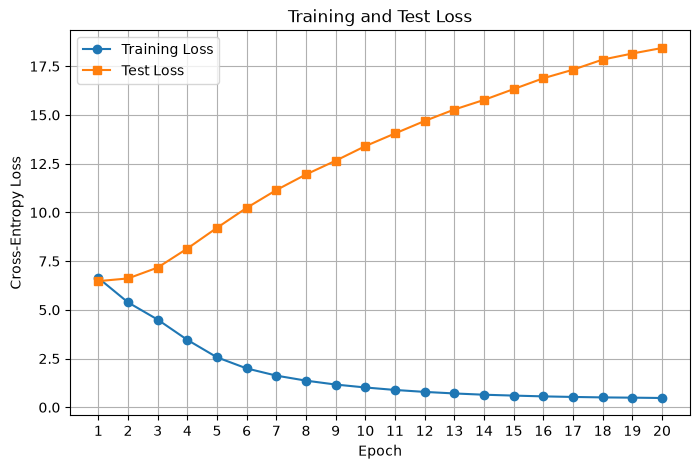

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    test_losses,
    marker="s",
    label="Test Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Test Loss")

plt.xticks(range(1, NUM_EPOCHS + 1))
plt.legend()
plt.grid(True)

plt.show()

In [78]:
import math

final_test_loss = test_losses[-1]

test_perplexity = math.exp(final_test_loss)

print(f"Final Test Loss       : {final_test_loss:.4f}")
print(f"Final Test Perplexity : {test_perplexity:.4f}")

Final Test Loss       : 18.4358
Final Test Perplexity : 101520916.4328


In [79]:
MODEL_PATH = "next_word_language_model.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: next_word_language_model.pth


In [80]:
loaded_model = NeuralLanguageModel(
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_size=HIDDEN_SIZE,
    context_size=CONTEXT_SIZE
)

loaded_model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

loaded_model = loaded_model.to(device)

loaded_model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [81]:
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print(f"Epochs              : {NUM_EPOCHS}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Optimizer           : Adam")
print(f"Loss function       : CrossEntropyLoss")
print(f"Embedding dimension : {EMBEDDING_DIM}")
print(f"Hidden size         : {HIDDEN_SIZE}")

print(f"\nFinal Train Loss    : {train_losses[-1]:.4f}")
print(f"Final Test Loss     : {test_losses[-1]:.4f}")
print(f"Test Perplexity     : {test_perplexity:.4f}")

TRAINING SUMMARY
Epochs              : 20
Batch size          : 64
Learning rate       : 0.001
Optimizer           : Adam
Loss function       : CrossEntropyLoss
Embedding dimension : 128
Hidden size         : 256

Final Train Loss    : 0.4772
Final Test Loss     : 18.4358
Test Perplexity     : 101520916.4328


In [82]:
## 10. Next-Word Prediction
def predict_next_word(
    context_words,
    model,
    word_to_idx,
    idx_to_word,
    device,
    top_k=5
):
    """
    Predict the next word given exactly 3 preceding words.

    Returns:
        predicted_word
        top_predictions
    """

    if len(context_words) != CONTEXT_SIZE:
        raise ValueError(
            f"Expected exactly {CONTEXT_SIZE} words."
        )

    # Convert words to IDs
    context_ids = [
        word_to_idx.get(
            word,
            word_to_idx["<UNK>"]
        )
        for word in context_words
    ]

    # Create tensor
    input_tensor = torch.tensor(
        [context_ids],
        dtype=torch.long,
        device=device
    )

    model.eval()

    with torch.no_grad():

        # Get logits
        logits = model(input_tensor)

        # Convert logits to probabilities
        probabilities = torch.softmax(
            logits,
            dim=1
        )

        # Get top-k predictions
        top_probs, top_indices = torch.topk(
            probabilities,
            k=top_k,
            dim=1
        )

    top_predictions = []

    for prob, idx in zip(
        top_probs[0],
        top_indices[0]
    ):
        word = idx_to_word[idx.item()]

        top_predictions.append(
            (word, prob.item())
        )

    predicted_word = top_predictions[0][0]

    return predicted_word, top_predictions

In [83]:
test_context = [
    word for word in test_sentences[0][:3]
]

print("Test context:", test_context)

Test context: ['terms', 'were', "n't"]


In [84]:
predicted_word, top_predictions = predict_next_word(
    test_context,
    model,
    word_to_idx,
    idx_to_word,
    device,
    top_k=5
)

print("\nPredicted word:", predicted_word)

print("\nTop-5 predictions:")

for rank, (word, probability) in enumerate(
    top_predictions,
    start=1
):
    print(
        f"{rank}. {word:<15} "
        f"{probability:.4f}"
    )


Predicted word: disclosed

Top-5 predictions:
1. disclosed       0.9994
2. have            0.0003
3. put             0.0002
4. without         0.0000
5. ``              0.0000


In [85]:
actual_word = test_sentences[0][3]

print("Context :", " ".join(test_context))
print("Actual  :", actual_word)
print("Predicted:", predicted_word)

Context : terms were n't
Actual  : disclosed
Predicted: disclosed


In [86]:
evaluation_sequences = []

for sentence in test_sentences:

    if len(sentence) <= CONTEXT_SIZE:
        continue

    for i in range(
        len(sentence) - CONTEXT_SIZE
    ):

        context = sentence[
            i:i + CONTEXT_SIZE
        ]

        target = sentence[
            i + CONTEXT_SIZE
        ]

        evaluation_sequences.append(
            (context, target)
        )

        if len(evaluation_sequences) == 10:
            break

    if len(evaluation_sequences) == 10:
        break

In [87]:
print(
    "Number of fixed evaluation sequences:",
    len(evaluation_sequences)
)

Number of fixed evaluation sequences: 10


In [88]:
prediction_results = []

for context, actual_word in evaluation_sequences:

    predicted_word, top_predictions = predict_next_word(
        context,
        model,
        word_to_idx,
        idx_to_word,
        device,
        top_k=5
    )

    prediction_results.append({
        "Context": " ".join(context),
        "Actual": actual_word,
        "Predicted": predicted_word,
        "Correct": predicted_word == actual_word
    })

In [89]:
prediction_df = pd.DataFrame(
    prediction_results
)

prediction_df

,Context,Actual,Predicted,Correct
0,terms were n't,disclosed,disclosed,True
1,were n't disclosed,*-1,*-1,True
2,n't disclosed *-1,.,for,False
3,`` at the,prices,s&p,False
4,at the prices,0,.,False
5,the prices 0,we,*t*-2,False
6,prices 0 we,were,'ve,False
7,0 we were,charged,n't,False
8,we were charged,*-78,*-1,False
9,were charged *-78,*t*-1,*,False


In [90]:
accuracy_10 = (
    prediction_df["Correct"].mean()
)

print(
    f"Accuracy on 10 fixed test sequences: "
    f"{accuracy_10:.2%}"
)

Accuracy on 10 fixed test sequences: 20.00%


In [91]:
def evaluate_accuracy(
    model,
    data_loader,
    device
):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    accuracy = correct / total

    return accuracy

In [92]:
test_accuracy = evaluate_accuracy(
    model,
    test_loader,
    device
)

print(
    f"Test Top-1 Accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Test Top-1 Accuracy: "
    f"{test_accuracy:.2%}"
)

Test Top-1 Accuracy: 0.1370
Test Top-1 Accuracy: 13.70%


In [93]:
def evaluate_top_k_accuracy(
    model,
    data_loader,
    device,
    k=5
):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in data_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            _, top_k_predictions = torch.topk(
                outputs,
                k=k,
                dim=1
            )

            matches = (
                top_k_predictions == y_batch.unsqueeze(1)
            )

            correct += matches.any(
                dim=1
            ).sum().item()

            total += y_batch.size(0)

    return correct / total

In [94]:
top5_accuracy = evaluate_top_k_accuracy(
    model,
    test_loader,
    device,
    k=5
)

print(
    f"Test Top-5 Accuracy: "
    f"{top5_accuracy:.2%}"
)

Test Top-5 Accuracy: 27.60%


In [95]:
detailed_results = []

for context, actual_word in evaluation_sequences:

    predicted_word, top_predictions = predict_next_word(
        context,
        model,
        word_to_idx,
        idx_to_word,
        device,
        top_k=5
    )

    top5_words = [
        word
        for word, probability
        in top_predictions
    ]

    detailed_results.append({
        "Context": " ".join(context),
        "Actual": actual_word,
        "Top-1 Prediction": predicted_word,
        "Top-5 Predictions": ", ".join(top5_words),
        "Top-1 Correct": predicted_word == actual_word,
        "Top-5 Correct": actual_word in top5_words
    })

detailed_df = pd.DataFrame(
    detailed_results
)

detailed_df

,Context,Actual,Top-1 Prediction,Top-5 Predictions,Top-1 Correct,Top-5 Correct
0,terms were n't,disclosed,disclosed,"disclosed, have, put, without, ``",True,True
1,were n't disclosed,*-1,*-1,"*-1, any, *-2, *-4, that",True,True
2,n't disclosed *-1,.,for,"for, ., ,, as, by",False,True
3,`` at the,prices,s&p,"s&p, end, big, company, constitutional",False,False
4,at the prices,0,.,"., u.s., 0, ,, began",False,True
5,the prices 0,we,*t*-2,"*t*-2, it, *t*-1, students, *",False,False
6,prices 0 we,were,'ve,"'ve, are, has, to, have",False,False
7,0 we were,charged,n't,"n't, interested, generally, broken, *t*-3",False,False
8,we were charged,*-78,*-1,"*-1, higher, *-3, large, .",False,False
9,were charged *-78,*t*-1,*,"*, fell, ,, with, *-1",False,False


In [96]:
context, actual_word = evaluation_sequences[0]

predicted_word, top_predictions = predict_next_word(
    context,
    model,
    word_to_idx,
    idx_to_word,
    device,
    top_k=5
)

print("Context:", " ".join(context))
print("Actual:", actual_word)

print("\nTop-5 predictions:")

for rank, (word, probability) in enumerate(
    top_predictions,
    start=1
):

    print(
        f"{rank}. {word:<15} "
        f"{probability:.4f}"
    )

Context: terms were n't
Actual: disclosed

Top-5 predictions:
1. disclosed       0.9994
2. have            0.0003
3. put             0.0002
4. without         0.0000
5. ``              0.0000


In [97]:
print("=" * 60)
print("FINAL MODEL EVALUATION")
print("=" * 60)

print(
    f"Test Cross-Entropy Loss : "
    f"{test_losses[-1]:.4f}"
)

print(
    f"Test Perplexity         : "
    f"{test_perplexity:.4f}"
)

print(
    f"Test Top-1 Accuracy     : "
    f"{test_accuracy:.2%}"
)

print(
    f"Test Top-5 Accuracy     : "
    f"{top5_accuracy:.2%}"
)

print(
    f"10-Sequence Accuracy    : "
    f"{accuracy_10:.2%}"
)

FINAL MODEL EVALUATION
Test Cross-Entropy Loss : 18.4358
Test Perplexity         : 101520916.4328
Test Top-1 Accuracy     : 13.70%
Test Top-5 Accuracy     : 27.60%
10-Sequence Accuracy    : 20.00%


In [98]:
unk_id = word_to_idx["<UNK>"]

unk_targets = (
    y_test_tensor == unk_id
).sum().item()

total_targets = len(y_test_tensor)

print(
    f"Test targets mapped to <UNK>: "
    f"{unk_targets:,}"
)

print(
    f"Percentage of test targets as <UNK>: "
    f"{100 * unk_targets / total_targets:.2f}%"
)

Test targets mapped to <UNK>: 1,210
Percentage of test targets as <UNK>: 6.99%


## 11. Evaluation and Observations

The trained neural language model predicts the next word using a fixed context of three preceding words.

The model uses an embedding layer to represent words as dense vectors, followed by one fully connected hidden layer with ReLU activation and an output layer corresponding to the vocabulary size.

The model performance is evaluated using test cross-entropy loss, perplexity, Top-1 accuracy, and Top-5 accuracy.

The prediction table demonstrates the model's ability to generate possible next words for unseen test contexts.

The training and test loss curves are used to examine the learning behavior of the model. A decreasing training loss indicates that the model is learning patterns from the training corpus. The relationship between training and test loss provides an indication of how well the model generalizes to unseen data.

The model is limited by its simple architecture and fixed three-word context. It cannot directly use longer contextual information, and words not present in the training vocabulary are represented using the <UNK> token.

Top-5 predictions provide additional information because multiple words can be plausible continuations of the same context.